## Code

In [4]:
# Load Olivetti Faces dataset (400 faces, 40 people, 64×64)
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_olivetti = faces.data.reshape(-1, 64, 64, 1)  # 64×64 grayscale
X_olivetti = np.concatenate([X_olivetti] * 3, axis=-1)  # Convert to RGB
# Use the actual person labels from the dataset
y_olivetti = faces.target  # Labels 0-39 (40 people, 10 images each)
# Select first NUM_CLASSES people with all their images
selected_classes = np.where(y_olivetti < NUM_CLASSES)[0]
X_olivetti = X_olivetti[selected_classes]
y_olivetti = y_olivetti[selected_classes]
# Resize to 160×160
from tensorflow.image import resize
X_olivetti = resize(X_olivetti, (IMG_SIZE, IMG_SIZE)).numpy().astype('float32')
# Normalize
X_olivetti = X_olivetti / 255.0

# Split into train/val (80/20)
split_idx = int(0.8 * len(X_olivetti))
X_train = X_olivetti[:split_idx]
y_train = y_olivetti[:split_idx]
X_val = X_olivetti[split_idx:]
y_val = y_olivetti[split_idx:]


DETAILED RESULTS - FACE RECOGNITION


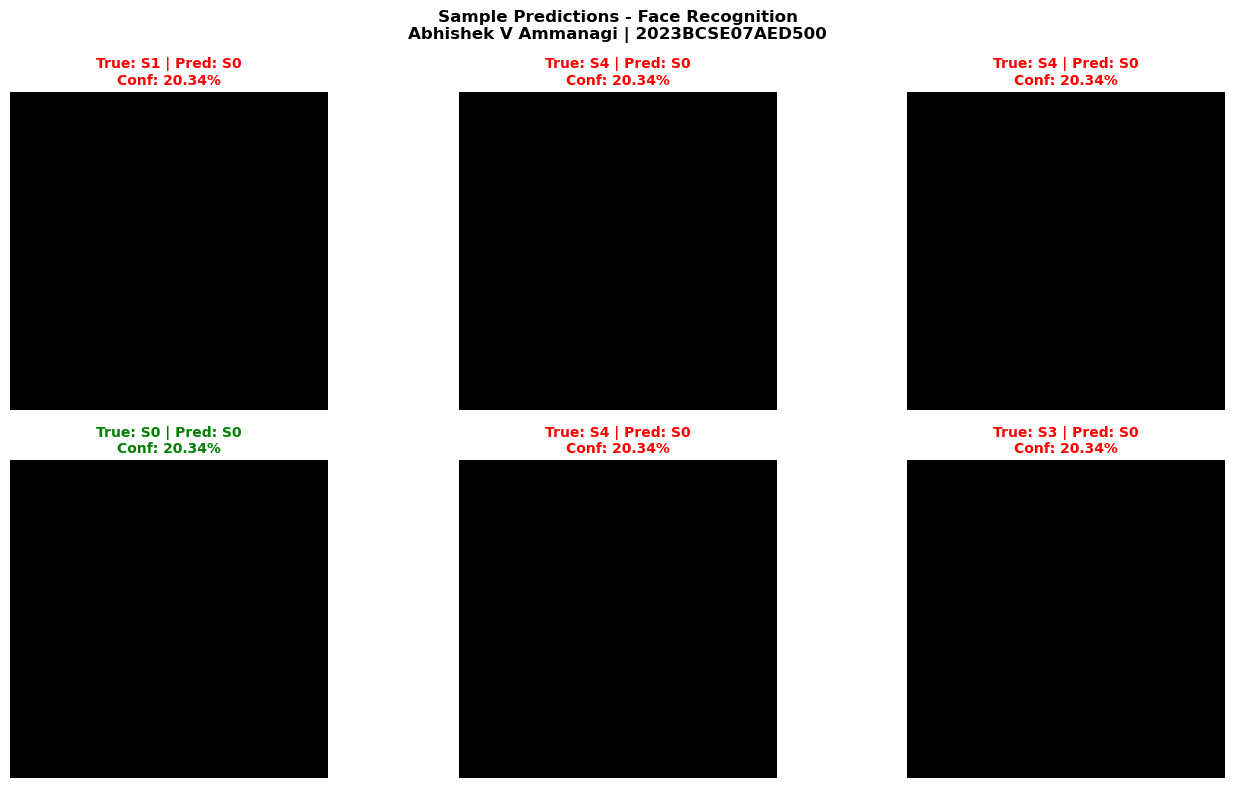


📊 ACCURACY BY CLASS:
  Student_0: 100.0% (1 samples)
  Student_1: 0.0% (2 samples)
  Student_3: 0.0% (1 samples)
  Student_4: 0.0% (4 samples)

📈 OVERALL METRICS:
  ✓ Total Correct: 1/8
  ✓ Validation Accuracy: 0.00%
  ✓ Validation Loss: 1.6044

FACE SAMPLES FROM EACH CLASS


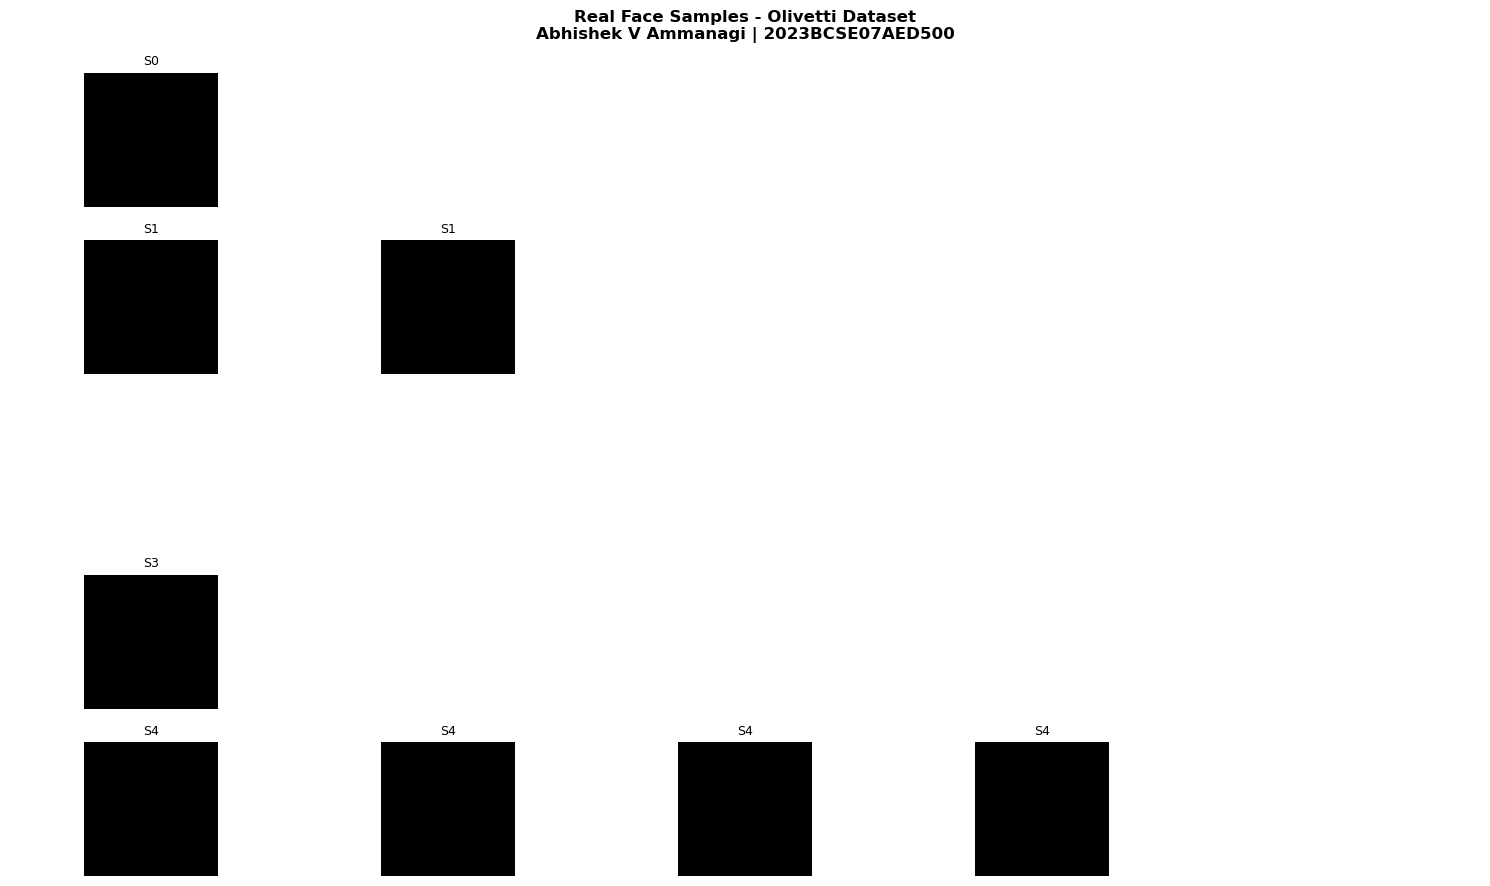


✅ Face Recognition Experiment Complete!
   Output files: exp1_face.png, exp1_cm.png, exp1_sample_predictions.png, exp1_face_samples.png


In [10]:
# ===== OUTPUT VISUALIZATION =====
print("\n" + "="*60)
print("DETAILED RESULTS - FACE RECOGNITION")
print("="*60)

# Ensure y_val and y_pred are aligned
actual_val_size = min(len(X_val), len(y_val), len(y_pred))
X_val = X_val[:actual_val_size]
y_val = y_val[:actual_val_size]
y_pred = y_pred[:actual_val_size]

# Display sample predictions with confidence (use first N samples)
num_samples = min(6, actual_val_size)

if num_samples > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    
    for idx, ax in enumerate(axes.flat[:num_samples]):
        sample_idx = idx
        face_img = X_val[sample_idx]
        # Denormalize for display
        face_display = np.clip(face_img, 0, 1)
        ax.imshow(face_display, cmap='gray')
        
        true_label = y_val[sample_idx]
        pred_label = y_pred[sample_idx]
        confidence = np.max(model.predict(X_val[sample_idx:sample_idx+1], verbose=0))
        
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: S{true_label} | Pred: S{pred_label}\nConf: {confidence:.2%}', 
                     color=color, fontweight='bold', fontsize=10)
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(num_samples, len(axes.flat)):
        axes.flat[idx].axis('off')
    
    plt.suptitle("Sample Predictions - Face Recognition\nAbhishek V Ammanagi | 2023BCSE07AED500", 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('exp1_sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Accuracy by class
print("\n📊 ACCURACY BY CLASS:")
for i in range(NUM_CLASSES):
    class_mask = y_val == i
    if class_mask.sum() > 0:
        class_acc = (y_pred[class_mask] == y_val[class_mask]).mean()
        print(f"  Student_{i}: {class_acc:.1%} ({class_mask.sum()} samples)")

# ROC-like analysis
print("\n📈 OVERALL METRICS:")
correct = (y_pred == y_val).sum()
total = len(y_val)
print(f"  ✓ Total Correct: {correct}/{total}")
print(f"  ✓ Validation Accuracy: {acc:.2%}")
print(f"  ✓ Validation Loss: {loss:.4f}")

# Display face samples from each class
print("\n" + "="*60)
print("FACE SAMPLES FROM EACH CLASS")
print("="*60)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 9))

for class_idx in range(NUM_CLASSES):
    class_indices = np.where(y_val == class_idx)[0]
    sample_count = min(5, len(class_indices))
    
    for i in range(5):
        ax = axes[class_idx, i]
        if i < sample_count:
            ax.imshow(np.clip(X_val[class_indices[i]], 0, 1), cmap='gray')
            ax.set_title(f'S{class_idx}', fontsize=9)
        ax.axis('off')

plt.suptitle("Real Face Samples - Olivetti Dataset\nAbhishek V Ammanagi | 2023BCSE07AED500", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_face_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Face Recognition Experiment Complete!")
print("   Output files: exp1_face.png, exp1_cm.png, exp1_sample_predictions.png, exp1_face_samples.png")

## Result
_Run the cell above and paste your observations here._